In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Embedding,Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')
print(f'Tensorflow version:{tf.__version__}')
print('All libraries imported!')

C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tensorflow version:2.21.0
All libraries imported!


In [3]:
#load clean transaction data
df=pd.read_csv('cognicart/data/cleaned/supermarket_clean.csv')
#sort by Customerid and date
df=df.sort_values(['Customer_ID','Date'])
print('Data loaded!')
print(f'Shape:{df.shape}')
print(f'Unique customers:{df['Customer_ID'].nunique()}')
print(f'Unique products:{df['Product'].nunique()}')
print()
print('Sample Data:')
print(df[['Customer_ID','Date','Product']].head(10))



Data loaded!
Shape:(27596, 13)
Unique customers:500
Unique products:43

Sample Data:
     Customer_ID        Date      Product
9815       C0001  2024-01-08        Chips
9816       C0001  2024-01-08  Wheat Flour
9817       C0001  2024-01-08        Bread
9818       C0001  2024-01-08      Shampoo
8327       C0001  2024-05-30       Coffee
8328       C0001  2024-05-30  Waterbottle
8329       C0001  2024-05-30        Bread
8330       C0001  2024-05-30          Tea
8331       C0001  2024-05-30   Cold Drink
8332       C0001  2024-05-30  Tomatosauce


In [4]:
#create label encoder for products
le=LabelEncoder()
#fit encoder on all products
df['ProductCode']=le.fit_transform(df['Product'])
#save mapping for later use
product_to_code=dict(zip(le.classes_,le.transform(le.classes_)))
code_to_product=dict(zip(le.transform(le.classes_),le.classes_))
NUM_PRODUCTS=len(le.classes_)
print(f'Total unique products:{NUM_PRODUCTS}')
print()
print('Product encoding examples:')
for product,code in list(product_to_code.items())[:8]:
    print(f'{product}-->{code}')

Total unique products:43

Product encoding examples:
Apple-->0
Banana-->1
Biscuit-->2
Biscuits-->3
Bread-->4
Brown Bread-->5
Butter-->6
Carrot-->7


In [5]:
#create purchase sequence
SEQUENCE_LENGTH=5#use last 5 purchase to predict next
x=[]#input sequences
y=[]#target next product
#group product by customer in order
customer_sequences=df.groupby('Customer_ID')['ProductCode'].apply(list)
for customer_id,products in customer_sequences.items():
    #need at least SEQUENCE_LENGTH+1 purchases
    if len(products)<SEQUENCE_LENGTH+1:
        continue
    #create sliding window sequences
    for i in range(len(products)-SEQUENCE_LENGTH):
        sequence=products[i:i+SEQUENCE_LENGTH]
        next_item=products[i+SEQUENCE_LENGTH]
        x.append(sequence)
        y.append(next_item)
x=np.array(x)
y=np.array(y)
print(f'Total training sequences:{len(x)}')
print(f'Sequence Shape:{x.shape}')
print()
print('Example sequence:')
print(f'input:{x[0]}={[code_to_product[c] for c in x[0]]}')
print(f'Target:{y[0]}={code_to_product[y[0]]}')

Total training sequences:25096
Sequence Shape:(25096, 5)

Example sequence:
input:[ 9 42  4 33 11]=['Chips', 'Wheat Flour', 'Bread', 'Shampoo', 'Coffee']
Target:41=Waterbottle


In [19]:
#convert target into onehotencoder
from sklearn.model_selection import train_test_split
y_encoded=to_categorical(y,num_classes=NUM_PRODUCTS)
x_train,x_test,y_train,y_test=train_test_split(
    x,y_encoded,
    test_size=0.2,
    random_state=42
)
print(f'training sample:{len(x_train)}')
print(f'testing sample:{len(x_test)}')
print(f'input sahpe:{x_train.shape}')
print(f'output shape:{y_train.shape}')


training sample:20076
testing sample:5020
input sahpe:(20076, 5)
output shape:(20076, 43)


In [29]:
#building LSTM model
model=Sequential([
    Embedding(
        input_dim=NUM_PRODUCTS,
        output_dim=64,
        input_length=SEQUENCE_LENGTH
    ),
    LSTM(
        units=128,
        return_sequences=True
    ),
    Dropout(0.3),
    LSTM(
        units=64,
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(128,activation='relu'),
    Dense(NUM_PRODUCTS,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
#compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.build(input_shape=(None, SEQUENCE_LENGTH))
print('Model compiled')
print(f'Total parameters:{model.count_params():,}')

Model compiled
Total parameters:164,843


In [39]:
#train model
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint=ModelCheckpoint(
    'cognicart/models/lstm_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
history=model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop,checkpoint],
    verbose=1
)
print('Training complete')

Epoch 1/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0779 - loss: 3.5653
Epoch 1: val_accuracy improved from None to 0.14542, saving model to cognicart/models/lstm_best.h5



Epoch 1: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.0977 - loss: 3.4490 - val_accuracy: 0.1454 - val_loss: 3.2031
Epoch 2/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1677 - loss: 3.1516
Epoch 2: val_accuracy improved from 0.14542 to 0.27092, saving model to cognicart/models/lstm_best.h5



Epoch 2: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1944 - loss: 3.0513 - val_accuracy: 0.2709 - val_loss: 2.8101
Epoch 3/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2674 - loss: 2.7991
Epoch 3: val_accuracy improved from 0.27092 to 0.31424, saving model to cognicart/models/lstm_best.h5



Epoch 3: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.2718 - loss: 2.7865 - val_accuracy: 0.3142 - val_loss: 2.6662
Epoch 4/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2932 - loss: 2.7202
Epoch 4: val_accuracy improved from 0.31424 to 0.33416, saving model to cognicart/models/lstm_best.h5



Epoch 4: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.2996 - loss: 2.6957 - val_accuracy: 0.3342 - val_loss: 2.5905
Epoch 5/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3123 - loss: 2.6410
Epoch 5: val_accuracy did not improve from 0.33416
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3150 - loss: 2.6381 - val_accuracy: 0.3287 - val_loss: 2.5535
Epoch 6/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3255 - loss: 2.5747
Epoch 6: val_accuracy improved from 0.33416 to 0.34960, saving model to cognicart/models/lstm_best.h5



Epoch 6: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3236 - loss: 2.5919 - val_accuracy: 0.3496 - val_loss: 2.5149
Epoch 7/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3355 - loss: 2.5486
Epoch 7: val_accuracy did not improve from 0.34960
565/565 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3357 - loss: 2.5474 - val_accuracy: 0.3416 - val_loss: 2.5179
Epoch 8/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3432 - loss: 2.4978
Epoch 8: val_accuracy did not improve from 0.34960
565/565 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3378 - loss: 2.5149 - val_accuracy: 0.3481 - val_loss: 2.4887
Epoch 9/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3450 - loss: 2.4787
Epoch 9: val_accuracy improved from 0.34960 to 0.35010, saving model to cognicart/models/lstm_best.h5



Epoch 9: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3448 - loss: 2.4809 - val_accuracy: 0.3501 - val_loss: 2.4939
Epoch 10/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3510 - loss: 2.4486
Epoch 10: val_accuracy did not improve from 0.35010
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3486 - loss: 2.4547 - val_accuracy: 0.3496 - val_loss: 2.4778
Epoch 11/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3543 - loss: 2.4146
Epoch 11: val_accuracy improved from 0.35010 to 0.35906, saving model to cognicart/models/lstm_best.h5



Epoch 11: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3516 - loss: 2.4288 - val_accuracy: 0.3591 - val_loss: 2.4678
Epoch 12/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3662 - loss: 2.3894
Epoch 12: val_accuracy did not improve from 0.35906
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3606 - loss: 2.3996 - val_accuracy: 0.3566 - val_loss: 2.4727
Epoch 13/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3541 - loss: 2.3785
Epoch 13: val_accuracy improved from 0.35906 to 0.36155, saving model to cognicart/models/lstm_best.h5



Epoch 13: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3629 - loss: 2.3736 - val_accuracy: 0.3616 - val_loss: 2.4613
Epoch 14/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3720 - loss: 2.3378
Epoch 14: val_accuracy improved from 0.36155 to 0.36853, saving model to cognicart/models/lstm_best.h5



Epoch 14: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3704 - loss: 2.3463 - val_accuracy: 0.3685 - val_loss: 2.4638
Epoch 15/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3762 - loss: 2.3127
Epoch 15: val_accuracy did not improve from 0.36853
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3735 - loss: 2.3236 - val_accuracy: 0.3571 - val_loss: 2.4659
Epoch 16/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3744 - loss: 2.2849
Epoch 16: val_accuracy did not improve from 0.36853
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3777 - loss: 2.2976 - val_accuracy: 0.3670 - val_loss: 2.4701
Epoch 17/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3831 - loss: 2.2577
Epoch 17: val_accuracy did not improve from 0.36853
565/565 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3806 - loss: 2.2786 - val_accuracy: 0.3625 - val_loss: 2.4677
Epoch 18/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 

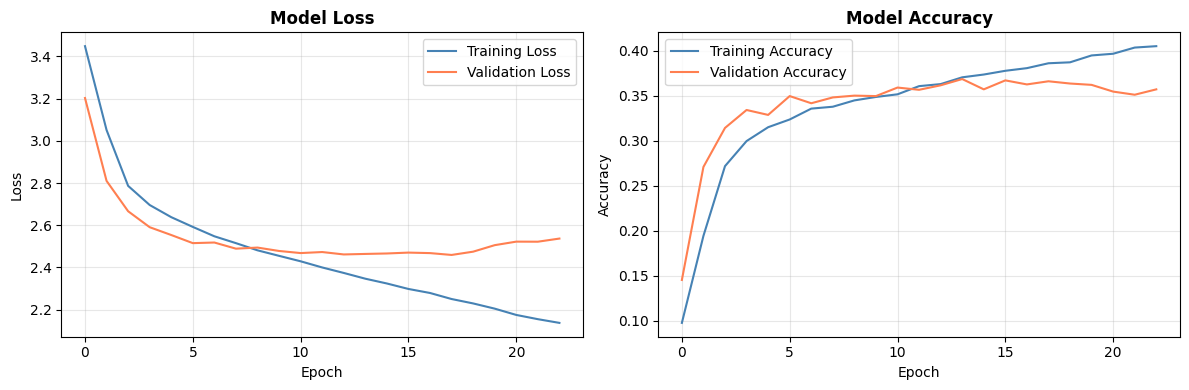

Training charts saved!


In [41]:
 fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],
             label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='coral')
axes[0].set_title('Model Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'],
             label='Training Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'],
             label='Validation Accuracy', color='coral')
axes[1].set_title('Model Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cognicart/outputs/week5_training.png', dpi=150)
plt.show()
print('Training charts saved!')


In [45]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')
print()

# Top-3 accuracy (predict in top 3 = correct)
predictions = model.predict(x_test)

top3_correct = 0
for i in range(len(predictions)):
    top3_preds = np.argsort(predictions[i])[-3:]
    true_label = np.argmax(y_test[i])
    if true_label in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(predictions)
print(f'Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.1f}%)')


Test Loss:     2.5121
Test Accuracy: 0.3442 (34.4%)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Top-3 Accuracy: 0.5528 (55.3%)


In [51]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')
print()

# Top-3 accuracy (predict in top 3 = correct)
predictions = model.predict(x_test)

top3_correct = 0
for i in range(len(predictions)):
    top3_preds = np.argsort(predictions[i])[-3:]
    true_label = np.argmax(y_test[i])
    if true_label in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(predictions)
print(f'Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.1f}%)')


Test Loss:     2.5121
Test Accuracy: 0.3442 (34.4%)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Top-3 Accuracy: 0.5528 (55.3%)


In [53]:
import pickle
import os

# Save final model
model.save('cognicart/models/lstm_final.h5')
print('LSTM model saved!')

# Save label encoder
with open('cognicart/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder saved!')

# Save product mappings
mappings = {
'product_to_code': product_to_code,
'code_to_product': code_to_product,
'num_products': NUM_PRODUCTS,
'sequence_length': SEQUENCE_LENGTH
}
with open('cognicart/models/product_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)
print('Product mappings saved!')
print()
print('All model files saved to cognicart/models/')


LSTM model saved!
Label encoder saved!
Product mappings saved!

All model files saved to cognicart/models/


In [57]:
print('=' * 55)
print('WEEK 5 COMPLETE!')
print('=' * 55)
print()
print('What you built this week:')
print('  Encoded products as numbers using LabelEncoder')
print('  Created purchase sequences using sliding window')
print('  Built LSTM neural network with Embedding layer')
print('  Trained model with EarlyStopping and Checkpoint')
print('  Evaluated model with Top-1 and Top-3 accuracy')
print('  Built predict_next_purchase() function')
print('  Saved model for use in dashboard')
print()
print('Model Performance:')
print(f'  Test Accuracy:    {test_accuracy*100:.1f}%')
print(f'  Top-3 Accuracy:   {top3_accuracy*100:.1f}%')
print()
print('Files saved:')
print('  cognicart/models/lstm_final.h5')
print('  cognicart/models/label_encoder.pkl')
print('  cognicart/models/product_mappings.pkl')
print('  cognicart/outputs/week5_training.png')
print()
print('Next Week: BERT NLP Embeddings (Week 6)!')


WEEK 5 COMPLETE!

What you built this week:
  Encoded products as numbers using LabelEncoder
  Created purchase sequences using sliding window
  Built LSTM neural network with Embedding layer
  Trained model with EarlyStopping and Checkpoint
  Evaluated model with Top-1 and Top-3 accuracy
  Built predict_next_purchase() function
  Saved model for use in dashboard

Model Performance:
  Test Accuracy:    34.4%
  Top-3 Accuracy:   55.3%

Files saved:
  cognicart/models/lstm_final.h5
  cognicart/models/label_encoder.pkl
  cognicart/models/product_mappings.pkl
  cognicart/outputs/week5_training.png

Next Week: BERT NLP Embeddings (Week 6)!
